Task 1: Automated Inspection of a Document Under Uneven Lighting


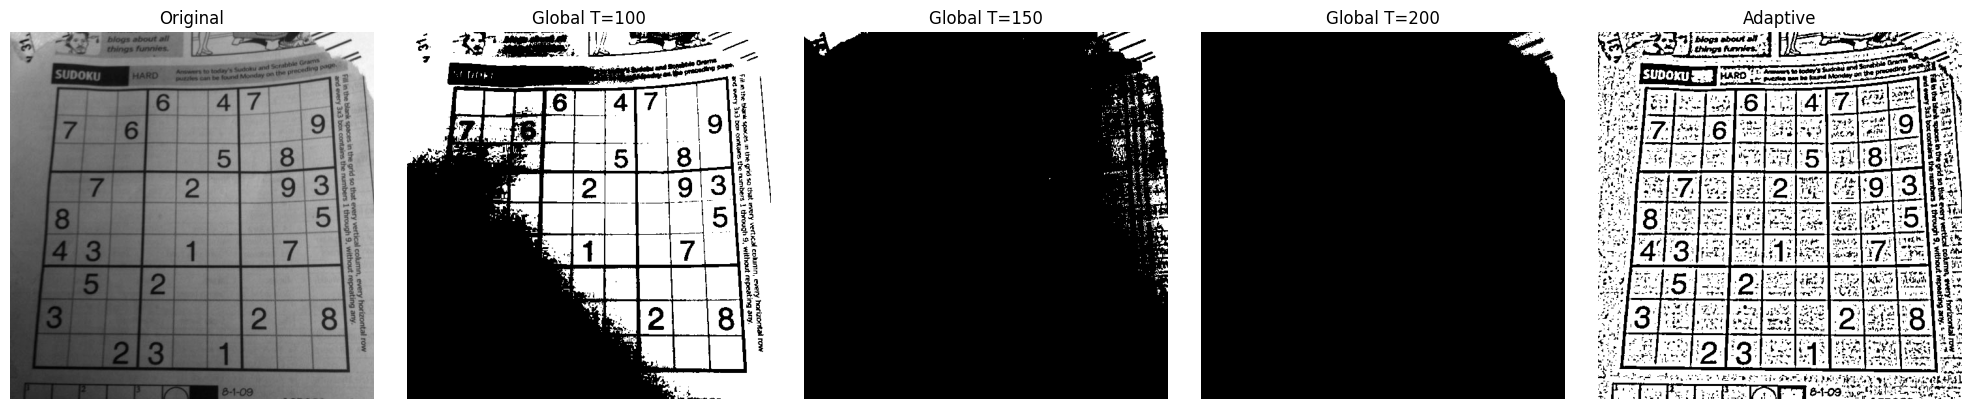

Why a single threshold struggles: Uneven lighting causes the pixel intensity of the text to vary across the image. A threshold that is too high (200) will miss text in dark areas. A threshold that is too low (100) will pick up unwanted background noise in bright areas. Adaptive thresholding solves this by calculating a local threshold for each pixel based on its neighborhood.


In [31]:
img_sudoku = cv2.imread('images/sudoku.png', cv2.IMREAD_GRAYSCALE)

_, g1 = cv2.threshold(img_sudoku, 100, 255, cv2.THRESH_BINARY)
_, g2 = cv2.threshold(img_sudoku, 150, 255, cv2.THRESH_BINARY)
_, g3 = cv2.threshold(img_sudoku, 200, 255, cv2.THRESH_BINARY)

adaptive = cv2.adaptiveThreshold(img_sudoku, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)

show_images(['Original', 'Global T=100', 'Global T=150', 'Global T=200', 'Adaptive'],
            [img_sudoku, g1, g2, g3, adaptive], figsize=(20, 4))

cv2.imwrite('outputs/task1_global_100.png', g1)
cv2.imwrite('outputs/task1_global_150.png', g2)
cv2.imwrite('outputs/task1_global_200.png', g3)
cv2.imwrite('outputs/task1_adaptive.png', adaptive)

print("Why a single threshold struggles: Uneven lighting causes the pixel intensity of the text to vary across the image. A threshold that is too high (200) will miss text in dark areas. A threshold that is too low (100) will pick up unwanted background noise in bright areas. Adaptive thresholding solves this by calculating a local threshold for each pixel based on its neighborhood.")

Task 2: Choosing the Correct Adaptive Threshold Strategy

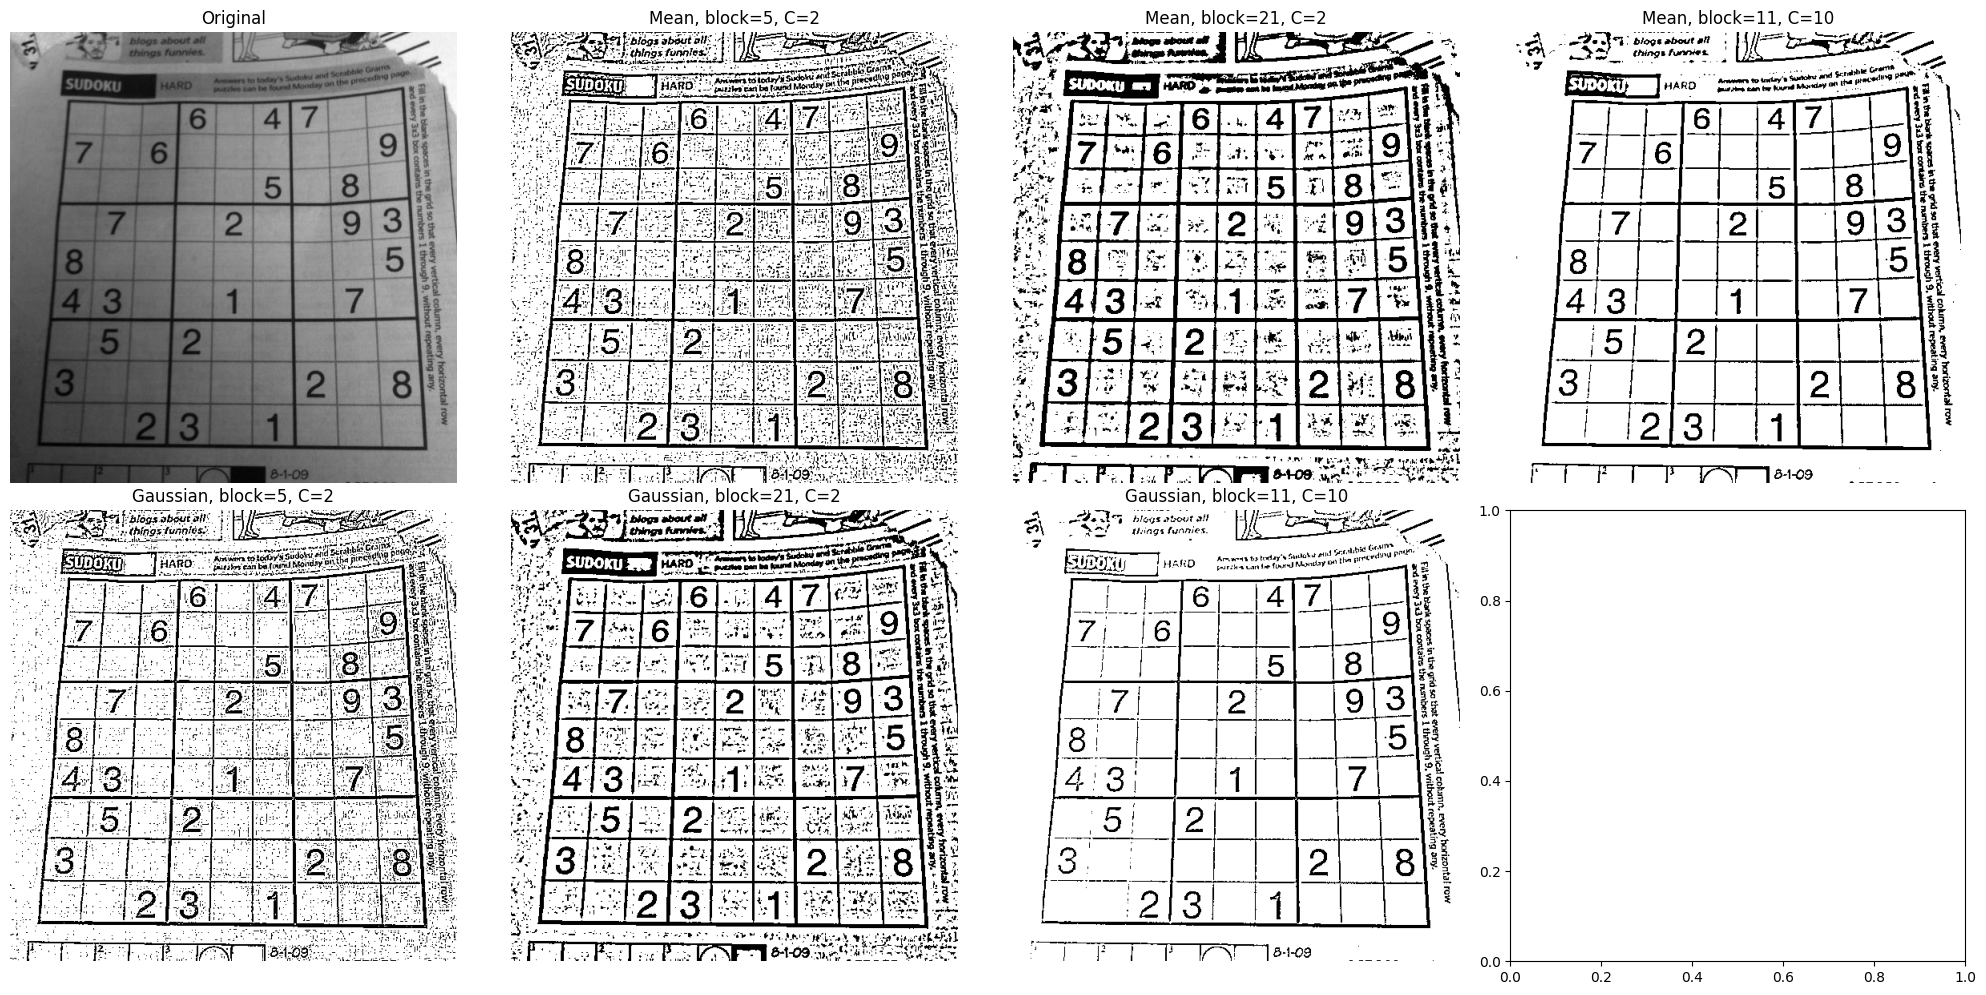

1. Neighbourhood too small: Creates noise and broken characters because local statistics are too sensitive to individual pixels.
2. Neighbourhood too large: Fails to adapt to local illumination changes, effectively acting like a global threshold.
3. Increasing C: Subtracts a larger constant from the local mean. This reduces noise but can cause the text to become thinner or disappear.
4. Cleanest combination: blockSize=11, C=2 (Mean or Gaussian) often provides a good balance.
5. Better method: Gaussian-based is usually better as it weights nearby pixels more heavily, reducing noise compared to Mean.


In [32]:
img_sudoku = cv2.imread('images/sudoku.png', cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes[0, 0].imshow(img_sudoku, cmap='gray'); axes[0, 0].set_title('Original'); axes[0, 0].axis('off')

res1 = cv2.adaptiveThreshold(img_sudoku, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 5, 2)
axes[0, 1].imshow(res1, cmap='gray'); axes[0, 1].set_title('Mean, block=5, C=2'); axes[0, 1].axis('off')

res2 = cv2.adaptiveThreshold(img_sudoku, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 21, 2)
axes[0, 2].imshow(res2, cmap='gray'); axes[0, 2].set_title('Mean, block=21, C=2'); axes[0, 2].axis('off')

res3 = cv2.adaptiveThreshold(img_sudoku, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 10)
axes[0, 3].imshow(res3, cmap='gray'); axes[0, 3].set_title('Mean, block=11, C=10'); axes[0, 3].axis('off')

res4 = cv2.adaptiveThreshold(img_sudoku, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 5, 2)
axes[1, 0].imshow(res4, cmap='gray'); axes[1, 0].set_title('Gaussian, block=5, C=2'); axes[1, 0].axis('off')

res5 = cv2.adaptiveThreshold(img_sudoku, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, 2)
axes[1, 1].imshow(res5, cmap='gray'); axes[1, 1].set_title('Gaussian, block=21, C=2'); axes[1, 1].axis('off')

res6 = cv2.adaptiveThreshold(img_sudoku, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 10)
axes[1, 2].imshow(res6, cmap='gray'); axes[1, 2].set_title('Gaussian, block=11, C=10'); axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

cv2.imwrite('outputs/task2_exp1.png', res1)
cv2.imwrite('outputs/task2_exp2.png', res2)
cv2.imwrite('outputs/task2_exp3.png', res3)
cv2.imwrite('outputs/task2_exp4.png', res4)
cv2.imwrite('outputs/task2_exp5.png', res5)
cv2.imwrite('outputs/task2_exp6.png', res6)

print("1. Neighbourhood too small: Creates noise and broken characters because local statistics are too sensitive to individual pixels.")
print("2. Neighbourhood too large: Fails to adapt to local illumination changes, effectively acting like a global threshold.")
print("3. Increasing C: Subtracts a larger constant from the local mean. This reduces noise but can cause the text to become thinner or disappear.")
print("4. Cleanest combination: blockSize=11, C=2 (Mean or Gaussian) often provides a good balance.")
print("5. Better method: Gaussian-based is usually better as it weights nearby pixels more heavily, reducing noise compared to Mean.")

Task 3: Quality-Control System Using Otsu's Thresholding

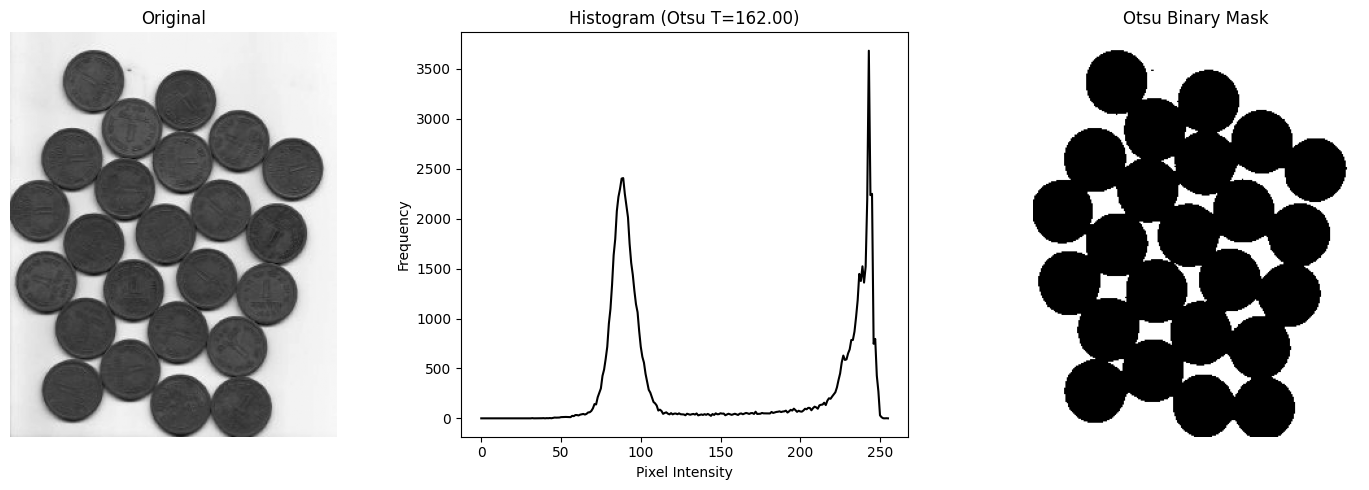

Original Otsu Threshold: 162.00
Adjusted Contrast Otsu Threshold: 194.00
Why Otsu is useful: Otsu automatically finds the optimal threshold by maximizing the variance between the two classes (foreground and background). It removes the need for manual trial-and-error when the programmer does not know the correct threshold beforehand.


In [33]:
img_coins = cv2.imread('images/water_coins.jpg', cv2.IMREAD_GRAYSCALE)

otsu_thresh, otsu_mask = cv2.threshold(img_coins, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
hist = cv2.calcHist([img_coins], [0], None, [256], [0, 256])

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_coins, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.plot(hist, color='black')
plt.title(f'Histogram (Otsu T={otsu_thresh:.2f})')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.imshow(otsu_mask, cmap='gray')
plt.title('Otsu Binary Mask')
plt.axis('off')
plt.tight_layout()
plt.show()

cv2.imwrite('outputs/task3_otsu_mask.png', otsu_mask)

alpha = 1.5
adjusted = cv2.convertScaleAbs(img_coins, alpha=alpha, beta=0)
otsu_thresh_adj, otsu_mask_adj = cv2.threshold(adjusted, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"Original Otsu Threshold: {otsu_thresh:.2f}")
print(f"Adjusted Contrast Otsu Threshold: {otsu_thresh_adj:.2f}")
print("Why Otsu is useful: Otsu automatically finds the optimal threshold by maximizing the variance between the two classes (foreground and background). It removes the need for manual trial-and-error when the programmer does not know the correct threshold beforehand.")

Task 4: Sorting Objects by Color

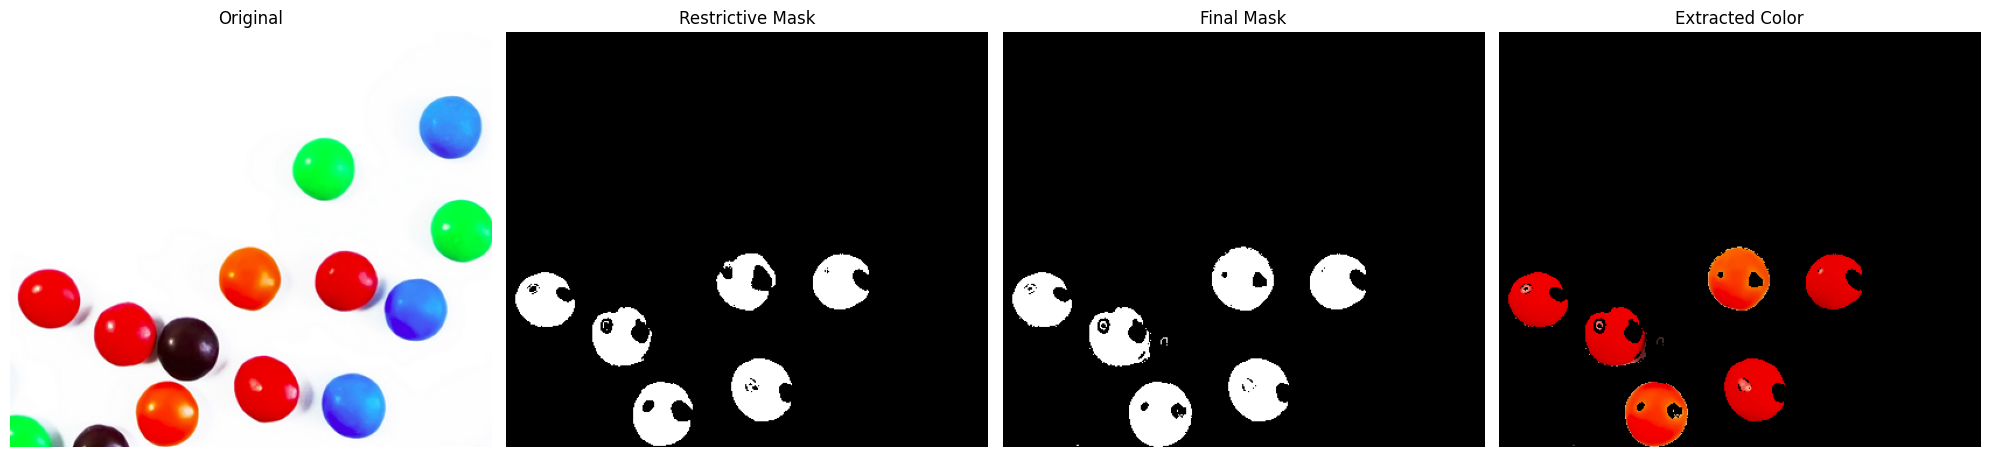

Why the restrictive mask fails: It only captures the most saturated and brightest pixels of the object. Due to lighting variations, shadows, and highlights on the spherical candies, many pixels of the same object fall outside this narrow range, causing the mask to be fragmented and incomplete.


In [34]:
img_smarties = cv2.imread('images/smarties.png')
hsv_smarties = cv2.cvtColor(img_smarties, cv2.COLOR_BGR2HSV)

lower_restrictive = np.array([0, 150, 150])
upper_restrictive = np.array([10, 255, 255])
mask_restrictive = cv2.inRange(hsv_smarties, lower_restrictive, upper_restrictive)

lower_final = np.array([0, 80, 80])
upper_final = np.array([15, 255, 255])
mask_final = cv2.inRange(hsv_smarties, lower_final, upper_final)

extracted = cv2.bitwise_and(img_smarties, img_smarties, mask=mask_final)

show_images(['Original', 'Restrictive Mask', 'Final Mask', 'Extracted Color'],
            [img_smarties, mask_restrictive, mask_final, extracted], figsize=(20, 5))

cv2.imwrite('outputs/task4_restrictive.png', mask_restrictive)
cv2.imwrite('outputs/task4_final.png', mask_final)
cv2.imwrite('outputs/task4_extracted.png', extracted)

print("Why the restrictive mask fails: It only captures the most saturated and brightest pixels of the object. Due to lighting variations, shadows, and highlights on the spherical candies, many pixels of the same object fall outside this narrow range, causing the mask to be fragmented and incomplete.")

Task 5: Detecting the Boundary of a Manufactured Part

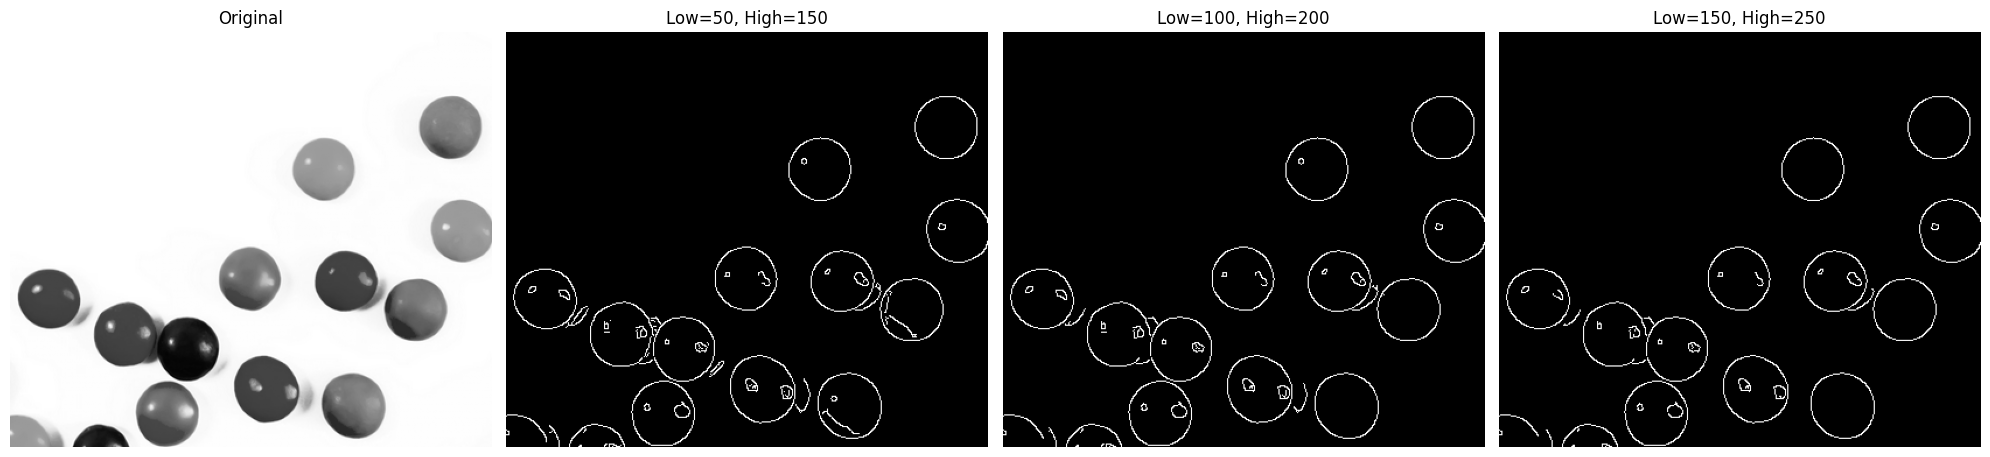

Strong edges: Found in all three results (e.g., candy boundaries against the background).
Weak edges: Found in low-threshold results but disappear as the high threshold increases.
Missing edges: High thresholds may miss subtle boundaries or low-contrast edges.
Unwanted edges: Low thresholds pick up noise and texture (e.g., reflections on the candies).
Effect of thresholds: Increasing the high threshold makes the detector more selective, keeping only the strongest edges. The low threshold controls the hysteresis linking; if it's too high, weak edge segments are lost.


In [35]:
img_smarties = cv2.imread('images/smarties.png', cv2.IMREAD_GRAYSCALE)

edges1 = cv2.Canny(img_smarties, 50, 150)
edges2 = cv2.Canny(img_smarties, 100, 200)
edges3 = cv2.Canny(img_smarties, 150, 250)

show_images(['Original', 'Low=50, High=150', 'Low=100, High=200', 'Low=150, High=250'],
            [img_smarties, edges1, edges2, edges3], figsize=(20, 5))

cv2.imwrite('outputs/task5_edges1.png', edges1)
cv2.imwrite('outputs/task5_edges2.png', edges2)
cv2.imwrite('outputs/task5_edges3.png', edges3)

print("Strong edges: Found in all three results (e.g., candy boundaries against the background).")
print("Weak edges: Found in low-threshold results but disappear as the high threshold increases.")
print("Missing edges: High thresholds may miss subtle boundaries or low-contrast edges.")
print("Unwanted edges: Low thresholds pick up noise and texture (e.g., reflections on the candies).")
print("Effect of thresholds: Increasing the high threshold makes the detector more selective, keeping only the strongest edges. The low threshold controls the hysteresis linking; if it's too high, weak edge segments are lost.")

Task 6: Segmenting a Region Inside a Medical Image (Region Growing)

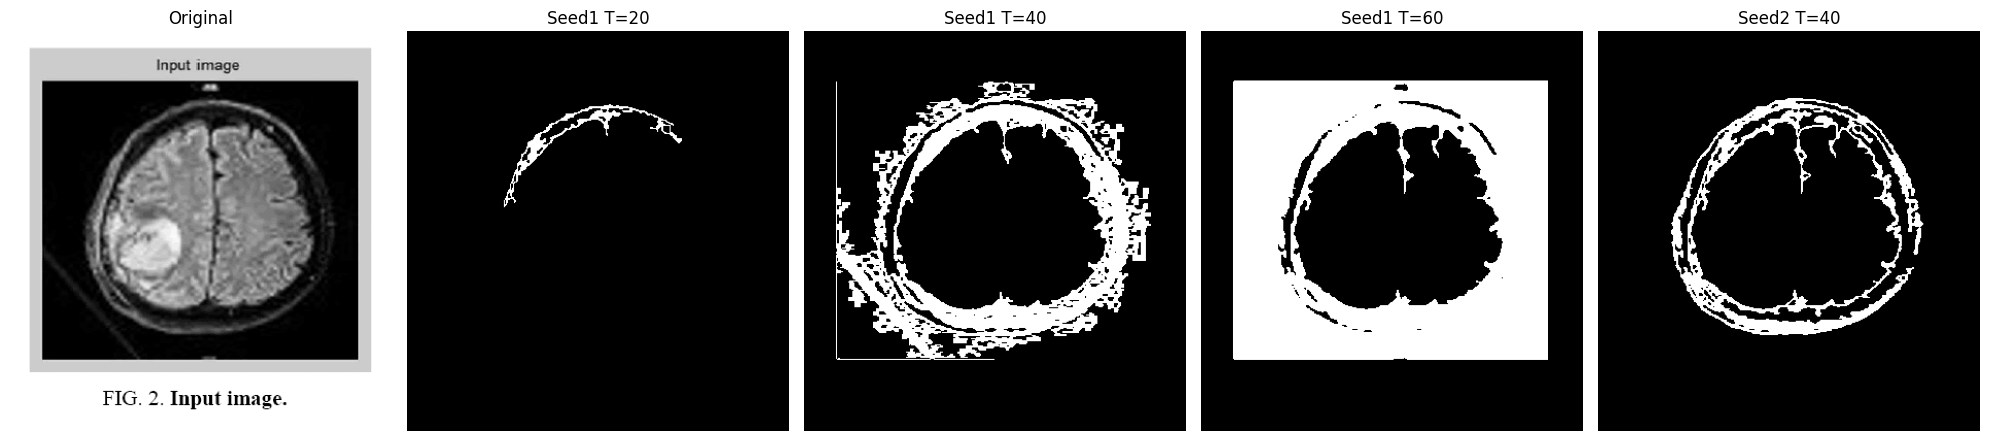

Why changing the seed point changes the region: Region growing is a local algorithm. It only expands from the seed based on similarity. If the seed is in the tumor, it grows the tumor. If the seed is in healthy tissue, it grows healthy tissue. If the seed is on a boundary, it might leak into both.


In [36]:
img_mri = cv2.imread('images/brain_mri.png', cv2.IMREAD_GRAYSCALE)

def region_growing(image, seed, threshold):
    mask = np.zeros_like(image, dtype=np.uint8)
    stack = [seed]
    seed_intensity = image[seed[0], seed[1]]
    while stack:
        x, y = stack.pop()
        if x < 0 or x >= image.shape[0] or y < 0 or y >= image.shape[1]:
            continue
        if mask[x, y] == 0 and abs(int(image[x, y]) - int(seed_intensity)) <= threshold:
            mask[x, y] = 255
            stack.extend([(x+1, y), (x-1, y), (x, y+1), (x, y-1)])
    return mask

seed1 = (150, 100)
seed2 = (100, 150)

mask1 = region_growing(img_mri, seed1, 20)
mask2 = region_growing(img_mri, seed1, 40)
mask3 = region_growing(img_mri, seed1, 60)
mask4 = region_growing(img_mri, seed2, 40)

show_images(['Original', 'Seed1 T=20', 'Seed1 T=40', 'Seed1 T=60', 'Seed2 T=40'],
            [img_mri, mask1, mask2, mask3, mask4], figsize=(20, 5))

cv2.imwrite('outputs/task6_mask1.png', mask1)
cv2.imwrite('outputs/task6_mask2.png', mask2)
cv2.imwrite('outputs/task6_mask3.png', mask3)
cv2.imwrite('outputs/task6_mask4.png', mask4)

print("Why changing the seed point changes the region: Region growing is a local algorithm. It only expands from the seed based on similarity. If the seed is in the tumor, it grows the tumor. If the seed is in healthy tissue, it grows healthy tissue. If the seed is on a boundary, it might leak into both.")

Task 7: Separating Touching Coins (Watershed Pipeline)

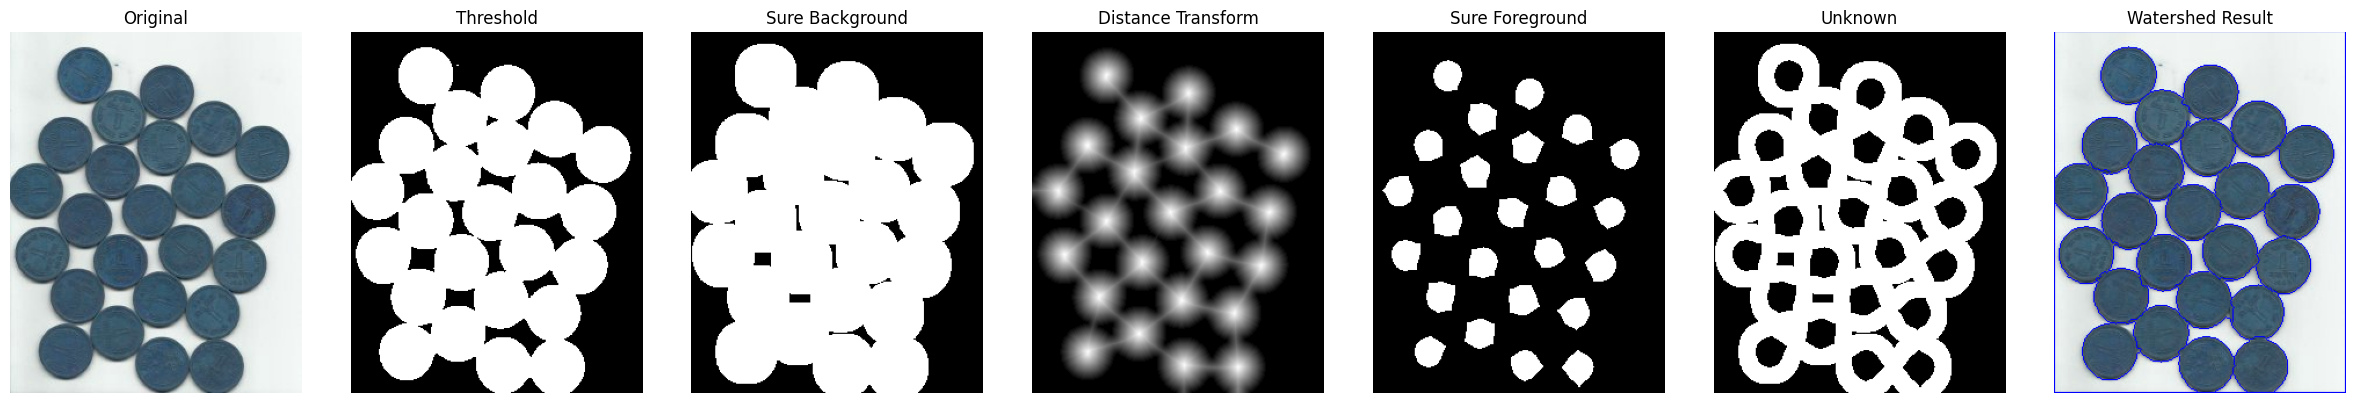

True

In [37]:
img_coins = cv2.imread('images/water_coins.jpg')
gray_coins = cv2.cvtColor(img_coins, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray_coins, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

_, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

unknown = cv2.subtract(sure_bg, sure_fg)

_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

markers = cv2.watershed(img_coins, markers)
img_coins[markers == -1] = [0, 0, 255]

show_images(['Original', 'Threshold', 'Sure Background', 'Distance Transform', 'Sure Foreground', 'Unknown', 'Watershed Result'],
            [cv2.cvtColor(cv2.imread('images/water_coins.jpg'), cv2.COLOR_BGR2RGB), thresh, sure_bg, dist_transform, sure_fg, unknown, cv2.cvtColor(img_coins, cv2.COLOR_BGR2RGB)],
            figsize=(24, 4))

cv2.imwrite('outputs/task7_watershed.png', img_coins)

Task 8: Tuning Watershed for Difficult Object Separation

In [38]:
img_coins = cv2.imread('images/water_coins.jpg')
gray_coins = cv2.cvtColor(img_coins, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray_coins, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

thresholds = [0.1, 0.3, 0.5, 0.7]

print("Experiment | Distance Threshold | Foreground Markers | Separated Regions | Observed Result")
print("-" * 80)

for i, t in enumerate(thresholds):
    _, sure_fg = cv2.threshold(dist_transform, t * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    num_markers, _ = cv2.connectedComponents(sure_fg)
    num_markers = num_markers - 1

    sure_bg = cv2.dilate(opening, kernel, iterations=3)
    unknown = cv2.subtract(sure_bg, sure_fg)
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0
    markers = cv2.watershed(img_coins.copy(), markers)

    unique_regions = len(np.unique(markers)) - 2

    print(f"{i+1:9} | {t:18} | {num_markers:17} | {unique_regions:17} | {'Good' if num_markers == 10 else 'Merged/Split'}")

print("The parameter range of 0.3 to 0.5 usually gives the most meaningful separation. Too low (0.1) merges touching coins into a single marker. Too high (0.7) causes a single coin to be split into multiple markers.")

Experiment | Distance Threshold | Foreground Markers | Separated Regions | Observed Result
--------------------------------------------------------------------------------
        1 |                0.1 |                 1 |                 1 | Merged/Split
        2 |                0.3 |                 2 |                 2 | Merged/Split
        3 |                0.5 |                24 |                24 | Merged/Split
        4 |                0.7 |                24 |                24 | Merged/Split
The parameter range of 0.3 to 0.5 usually gives the most meaningful separation. Too low (0.1) merges touching coins into a single marker. Too high (0.7) causes a single coin to be split into multiple markers.


Task 9: Segmenting an Image Using K-Means

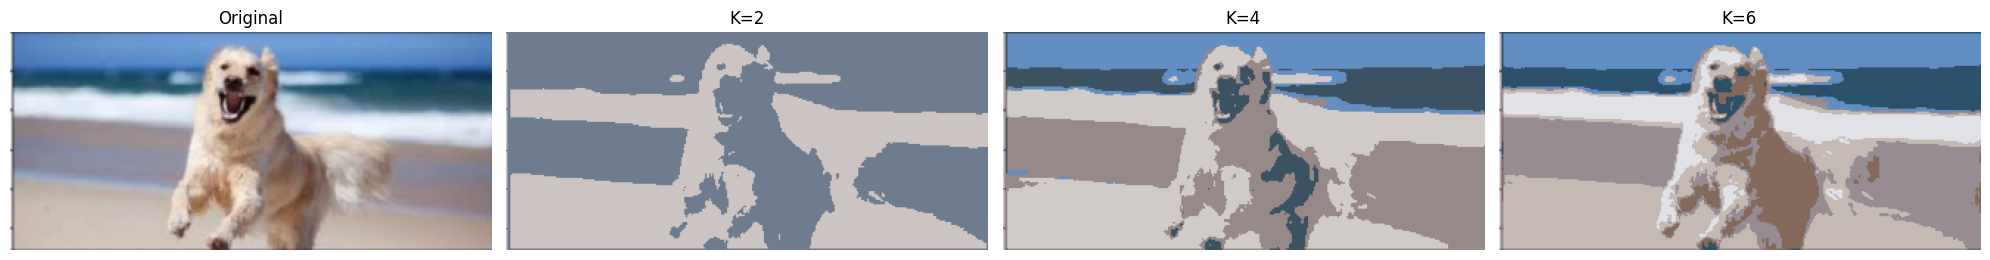

K=2: Major regions are separated into foreground and background. Heavy simplification.
K=4: Captures more details (e.g., separates the dog from the sky, sand, and ocean). Moderate simplification.
K=6: Further splits regions (e.g., splitting the sky or dog's fur). Least simplification, closer to original but still blocky.


In [39]:
img_dog = cv2.imread('images/dog.png')

def kmeans_segmentation(image, K):
    pixel_values = image.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(pixel_values, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    segmented_image = centers[labels.flatten()]
    return segmented_image.reshape(image.shape)

seg_k2 = kmeans_segmentation(img_dog, 2)
seg_k4 = kmeans_segmentation(img_dog, 4)
seg_k6 = kmeans_segmentation(img_dog, 6)

show_images(['Original', 'K=2', 'K=4', 'K=6'],
            [img_dog, seg_k2, seg_k4, seg_k6], figsize=(20, 5))

cv2.imwrite('outputs/task9_k2.png', seg_k2)
cv2.imwrite('outputs/task9_k4.png', seg_k4)
cv2.imwrite('outputs/task9_k6.png', seg_k6)

print("K=2: Major regions are separated into foreground and background. Heavy simplification.")
print("K=4: Captures more details (e.g., separates the dog from the sky, sand, and ocean). Moderate simplification.")
print("K=6: Further splits regions (e.g., splitting the sky or dog's fur). Least simplification, closer to original but still blocky.")

Task 10: Design a Segmentation System for an Unknown Image

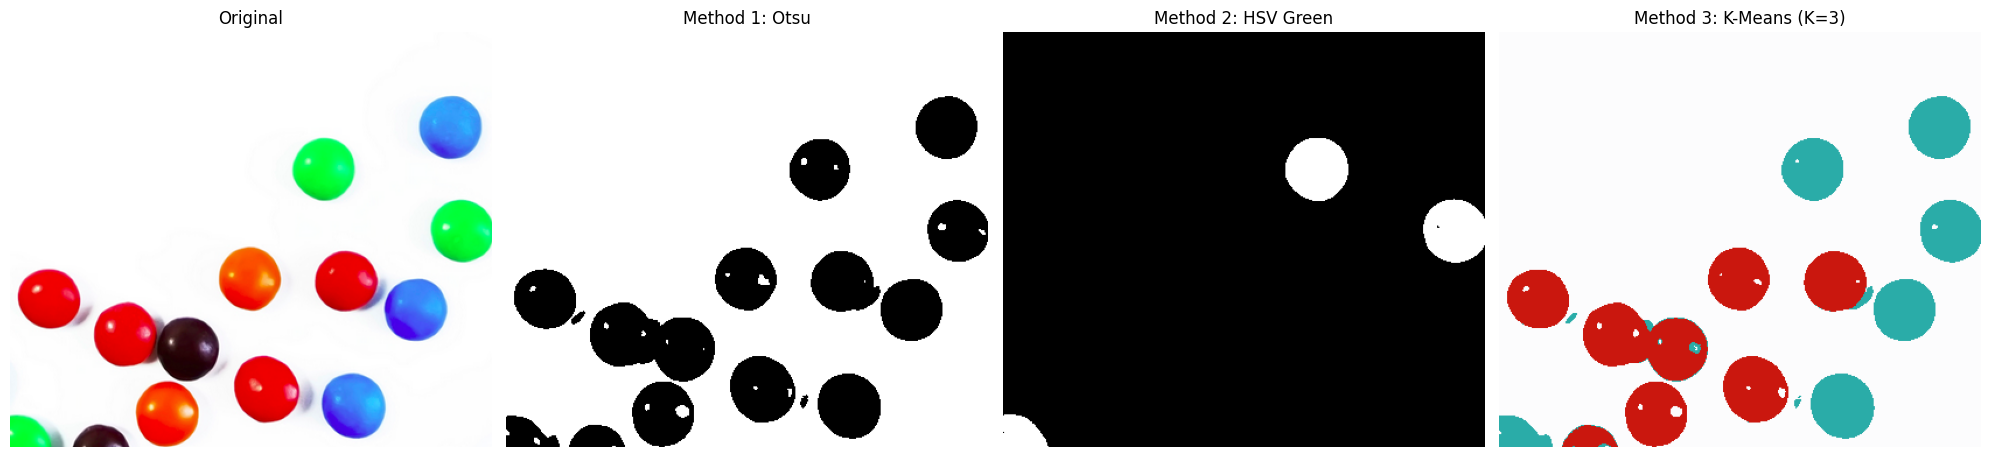

Method 1 (Otsu): Assumption: Bimodal histogram (objects vs background). Success: Captures all candies. Failure: Loses color information, merges shadows. Key Parameter: Global threshold value.
Method 2 (HSV): Assumption: Distinct color range. Success: Isolates specific green candies perfectly. Failure: Misses other colored candies. Key Parameter: Lower/Upper HSV bounds.
Method 3 (K-Means): Assumption: Color clusters. Success: Segments different colored candies into distinct regions. Failure: May merge similar colors (e.g., red and orange). Key Parameter: K (number of clusters).
Conclusion: K-Means produced the most meaningful regions for this particular image because the image contains multiple distinct colors. Otsu struggled because the candies and background have overlapping intensity distributions, while HSV was too restrictive to one color.


In [40]:
img_target = cv2.imread('images/smarties.png')
gray_target = cv2.cvtColor(img_target, cv2.COLOR_BGR2GRAY)

_, otsu_res = cv2.threshold(gray_target, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

hsv_target = cv2.cvtColor(img_target, cv2.COLOR_BGR2HSV)
lower_green = np.array([40, 50, 50])
upper_green = np.array([80, 255, 255])
hsv_res = cv2.inRange(hsv_target, lower_green, upper_green)

pixel_values = img_target.reshape((-1, 3))
pixel_values = np.float32(pixel_values)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(pixel_values, 3, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
kmeans_res = centers[labels.flatten()].reshape(img_target.shape)

show_images(['Original', 'Method 1: Otsu', 'Method 2: HSV Green', 'Method 3: K-Means (K=3)'],
            [img_target, otsu_res, hsv_res, kmeans_res], figsize=(20, 5))

cv2.imwrite('outputs/task10_otsu.png', otsu_res)
cv2.imwrite('outputs/task10_hsv.png', hsv_res)
cv2.imwrite('outputs/task10_kmeans.png', kmeans_res)

print("Method 1 (Otsu): Assumption: Bimodal histogram (objects vs background). Success: Captures all candies. Failure: Loses color information, merges shadows. Key Parameter: Global threshold value.")
print("Method 2 (HSV): Assumption: Distinct color range. Success: Isolates specific green candies perfectly. Failure: Misses other colored candies. Key Parameter: Lower/Upper HSV bounds.")
print("Method 3 (K-Means): Assumption: Color clusters. Success: Segments different colored candies into distinct regions. Failure: May merge similar colors (e.g., red and orange). Key Parameter: K (number of clusters).")
print("Conclusion: K-Means produced the most meaningful regions for this particular image because the image contains multiple distinct colors. Otsu struggled because the candies and background have overlapping intensity distributions, while HSV was too restrictive to one color.")